In [85]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [86]:
# 🔹 Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [87]:
# 🔹 Normalize data (0-255 → 0-1)
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

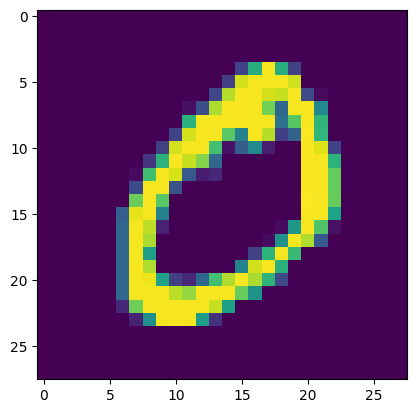

In [88]:
plt.imshow(x_train[1])

In [43]:
# 🔹 Normalize data (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [44]:
# 🔹 Flatten (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [61]:
# 🔹 Build ANN Model

model = Sequential()

model.add(Dense(128, activation='relu', input_shape = (784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='softmax'))  # 10 classes


In [62]:
# 🔹 Compile Model

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [63]:
# 🔹 Train Model

history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9113 - loss: 0.3142 - val_accuracy: 0.9652 - val_loss: 0.1218
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9652 - loss: 0.1151 - val_accuracy: 0.9700 - val_loss: 0.0961
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9752 - loss: 0.0791 - val_accuracy: 0.9778 - val_loss: 0.0863
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9811 - loss: 0.0606 - val_accuracy: 0.9752 - val_loss: 0.0775
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0456 - val_accuracy: 0.9757 - val_loss: 0.0855
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9881 - loss: 0.0370 - val_accuracy: 0.9765 - val_loss: 0.0871
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9896 - loss: 0.0315 - val_accuracy: 0.9775 - val_loss: 0.0849
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0253 - 

In [64]:
# 🔹 Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9767 - loss: 0.1022


In [65]:
print(f"\nTest Accuracy: {test_acc}")


Test Accuracy: 0.9767000079154968


In [66]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [67]:
y_pred = y_pred.argmax(axis=1)

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
accuracy_score(y_test, y_pred)

0.9767

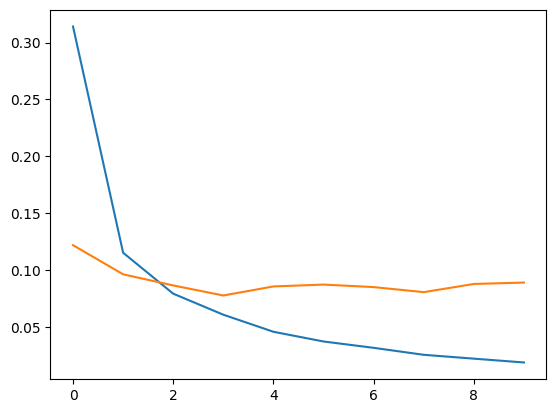

In [70]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [81]:
print('Actual : ', y_pred[5])
print('Actual : ', y_test[5])

Actual :  1
Actual :  1


In [90]:
model.predict(x_train[1].reshape(-1, 28*28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([0])